# Adult experiments

Contextual bandit pipeline on the Adult dataset.

### Load config

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from fair_bandits.config import build_config
from fair_bandits.data import (
    load_adult,
    prepare_adult_contextual,
    make_group_label_sampling_probs,
)
from fair_bandits.policies import LinUCB, GroupAwareDPLinUCB
from fair_bandits.experiments import (
    run_multi_seed_bandit_experiment,
    summarize_over_seeds,
    compare_methods,
)
from fair_bandits.io import (
    export_experiment_bundle,
    experiment_bundle_exists,
    load_experiment_bundle,
)
from fair_bandits.plots import (
    plot_average_reward_over_time,
    plot_rolling_reward,
    plot_dp_gap_over_time,
    plot_benchmark_bars,
)


### Load and prepare data

In [2]:
CFG = build_config("full")   # switch to "full" for thesis figures

DATASET_NAME = "ADULT"
SENSITIVE_COLS = ["sex", "race"]
PREPROCESSING_OPTIONS = ["uniform", "reweigh_group_label"]

RUN_MISSING = True
ROLLING_WINDOW = 50

CFG


ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

In [3]:
policy_factories = {
    "LinUCB": lambda d, groups, seed: LinUCB(
        d=d,
        alpha=CFG.alpha_linucb,
        lam=CFG.lambda_ridge,
        n_actions=2,
    ),
    "GroupAwareDPLinUCB": lambda d, groups, seed: GroupAwareDPLinUCB(
        d=d,
        groups=groups,
        alpha=CFG.alpha_linucb,
        lam=CFG.lambda_ridge,
        tau=CFG.dp_tau,
        lambda_fair=CFG.dp_lambda,
        beta_smooth=CFG.beta_smooth,
        min_group_count=CFG.min_group_count,
        n_actions=2,
    ),
}


In [4]:
adult_df = load_adult()

print("Adult shape:", adult_df.shape)
display(adult_df.head())


Adult shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Load and run cached experiments

In [5]:
def build_run_dir(cfg, dataset_name: str, sensitive_col: str, preprocessing: str) -> Path:
    run_dir = (
        cfg.results_dir
        / dataset_name.lower()
        / f"sensitive_{sensitive_col}"
        / preprocessing
    )
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def run_one_condition(cfg, df, *, sensitive_col: str, preprocessing: str):
    X, y, group, feature_names, meta = prepare_adult_contextual(
        df,
        sensitive_col=sensitive_col,
    )

    sampling_probs = None
    if preprocessing == "reweigh_group_label":
        sampling_probs = make_group_label_sampling_probs(group, y)

    run_dir = build_run_dir(cfg, DATASET_NAME, sensitive_col, preprocessing)

    if experiment_bundle_exists(run_dir):
        bundle = load_experiment_bundle(run_dir)
        print(f"Loaded cached results: {run_dir}")
    else:
        if not RUN_MISSING:
            raise FileNotFoundError(f"Missing cached results for {run_dir}")

        bundle = run_multi_seed_bandit_experiment(
            X=X,
            y=y,
            group=group,
            policy_factories=policy_factories,
            horizon=CFG.T_contextual,
            n_seeds=CFG.n_seeds,
            seed0=CFG.seed0,
            sampling_probs=sampling_probs,
            replace=True,
            rolling_window=ROLLING_WINDOW,
            condition_cols={
                "dataset": DATASET_NAME,
                "sensitive": sensitive_col,
                "preprocessing": preprocessing,
            },
        )
        export_experiment_bundle(bundle, run_dir)
        print(f"Saved results: {run_dir}")

    return bundle


In [6]:
bundles = {}

for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSING_OPTIONS:
        key = (sensitive_col, preprocessing)
        bundles[key] = run_one_condition(
            CFG,
            adult_df,
            sensitive_col=sensitive_col,
            preprocessing=preprocessing,
        )


Saved results: results\full\adult\sensitive_sex\uniform
Saved results: results\full\adult\sensitive_sex\reweigh_group_label
Saved results: results\full\adult\sensitive_race\uniform
Saved results: results\full\adult\sensitive_race\reweigh_group_label


### Aggregate results

In [7]:
seed_summary_all = pd.concat(
    [bundle.seed_summary for bundle in bundles.values()],
    ignore_index=True,
)

logs_all = pd.concat(
    [bundle.logs for bundle in bundles.values()],
    ignore_index=True,
)

agg_summary = summarize_over_seeds(
    seed_summary_all,
    group_cols=["dataset", "sensitive", "preprocessing", "policy"],
)

display(agg_summary.sort_values(["sensitive", "preprocessing", "policy"]).reset_index(drop=True))


,dataset,sensitive,preprocessing,policy,n_seeds,accuracy_mean,accuracy_low,accuracy_high,DP_gap_mean,DP_gap_low,...,final_avg_reward_high,final_rolling_reward_mean,final_rolling_reward_low,final_rolling_reward_high,final_dp_gap_mean,final_dp_gap_low,final_dp_gap_high,final_cum_regret_mean,final_cum_regret_low,final_cum_regret_high
0,ADULT,race,reweigh_group_label,GroupAwareDPLinUCB,50,0.832672,0.819304,0.838762,0.052977,0.041591,...,0.838762,0.8344,0.7200,0.9155,0.052977,0.041591,0.062452,5019.84,4837.150,5420.875
1,ADULT,race,reweigh_group_label,LinUCB,50,0.831949,0.821955,0.838302,0.079846,0.057359,...,0.838302,0.8324,0.7200,0.9155,0.079846,0.057359,0.100272,5041.54,4850.950,5341.350
2,ADULT,race,uniform,GroupAwareDPLinUCB,50,0.831548,0.824408,0.839313,0.151982,0.113189,...,0.839313,0.8204,0.7090,0.9000,0.151982,0.113189,0.220355,5053.56,4820.600,5267.750
3,ADULT,race,uniform,LinUCB,50,0.832031,0.825594,0.838950,0.242513,0.162289,...,0.838950,0.8272,0.7245,0.9000,0.242513,0.162289,0.361817,5039.06,4831.500,5232.175
4,ADULT,sex,reweigh_group_label,GroupAwareDPLinUCB,50,0.813931,0.806712,0.818526,0.047533,0.035654,...,0.818526,0.8244,0.7045,0.9200,0.047533,0.035654,0.066088,5582.08,5444.225,5798.650
5,ADULT,sex,reweigh_group_label,LinUCB,50,0.813709,0.805419,0.818906,0.058467,0.041017,...,0.818906,0.8232,0.7135,0.9155,0.058467,0.041017,0.075926,5588.72,5432.825,5837.425
6,ADULT,sex,uniform,GroupAwareDPLinUCB,50,0.829859,0.821874,0.838303,0.113569,0.104556,...,0.838303,0.8272,0.7135,0.9000,0.113569,0.104556,0.122149,5104.22,4850.900,5343.775
7,ADULT,sex,uniform,LinUCB,50,0.832265,0.824572,0.838737,0.158662,0.146072,...,0.838737,0.8276,0.7090,0.9000,0.158662,0.146072,0.171834,5032.04,4837.900,5262.850


### Generate figures

In [8]:
table_cols = [
    "dataset",
    "sensitive",
    "preprocessing",
    "policy",
    "accuracy_mean", "accuracy_low", "accuracy_high",
    "DP_gap_mean", "DP_gap_low", "DP_gap_high",
    "EO_gap_mean", "EO_gap_low", "EO_gap_high",
    "PPV_gap_mean", "PPV_gap_low", "PPV_gap_high",
    "CumulativeRegret_mean", "CumulativeRegret_low", "CumulativeRegret_high",
]

display(
    agg_summary[table_cols]
    .sort_values(["sensitive", "preprocessing", "policy"])
    .reset_index(drop=True)
)


,dataset,sensitive,preprocessing,policy,accuracy_mean,accuracy_low,accuracy_high,DP_gap_mean,DP_gap_low,DP_gap_high,EO_gap_mean,EO_gap_low,EO_gap_high,PPV_gap_mean,PPV_gap_low,PPV_gap_high,CumulativeRegret_mean,CumulativeRegret_low,CumulativeRegret_high
0,ADULT,race,reweigh_group_label,GroupAwareDPLinUCB,0.832672,0.819304,0.838762,0.052977,0.041591,0.062452,0.124015,0.103412,0.145752,0.097594,0.073174,0.114800,5019.84,4837.150,5420.875
1,ADULT,race,reweigh_group_label,LinUCB,0.831949,0.821955,0.838302,0.079846,0.057359,0.100272,0.145176,0.120478,0.169447,0.107504,0.081456,0.127868,5041.54,4850.950,5341.350
2,ADULT,race,uniform,GroupAwareDPLinUCB,0.831548,0.824408,0.839313,0.151982,0.113189,0.220355,0.148478,0.075752,0.283303,0.324507,0.203003,0.454490,5053.56,4820.600,5267.750
3,ADULT,race,uniform,LinUCB,0.832031,0.825594,0.838950,0.242513,0.162289,0.361817,0.307558,0.168426,0.517224,0.321120,0.169362,0.452601,5039.06,4831.500,5232.175
4,ADULT,sex,reweigh_group_label,GroupAwareDPLinUCB,0.813931,0.806712,0.818526,0.047533,0.035654,0.066088,0.117179,0.102109,0.139160,0.092170,0.077298,0.104866,5582.08,5444.225,5798.650
5,ADULT,sex,reweigh_group_label,LinUCB,0.813709,0.805419,0.818906,0.058467,0.041017,0.075926,0.127979,0.110335,0.140154,0.098153,0.083044,0.108058,5588.72,5432.825,5837.425
6,ADULT,sex,uniform,GroupAwareDPLinUCB,0.829859,0.821874,0.838303,0.113569,0.104556,0.122149,0.040056,0.026431,0.064958,0.153926,0.116972,0.195443,5104.22,4850.900,5343.775
7,ADULT,sex,uniform,LinUCB,0.832265,0.824572,0.838737,0.158662,0.146072,0.171834,0.088977,0.061686,0.127198,0.109675,0.065850,0.162600,5032.04,4837.900,5262.850


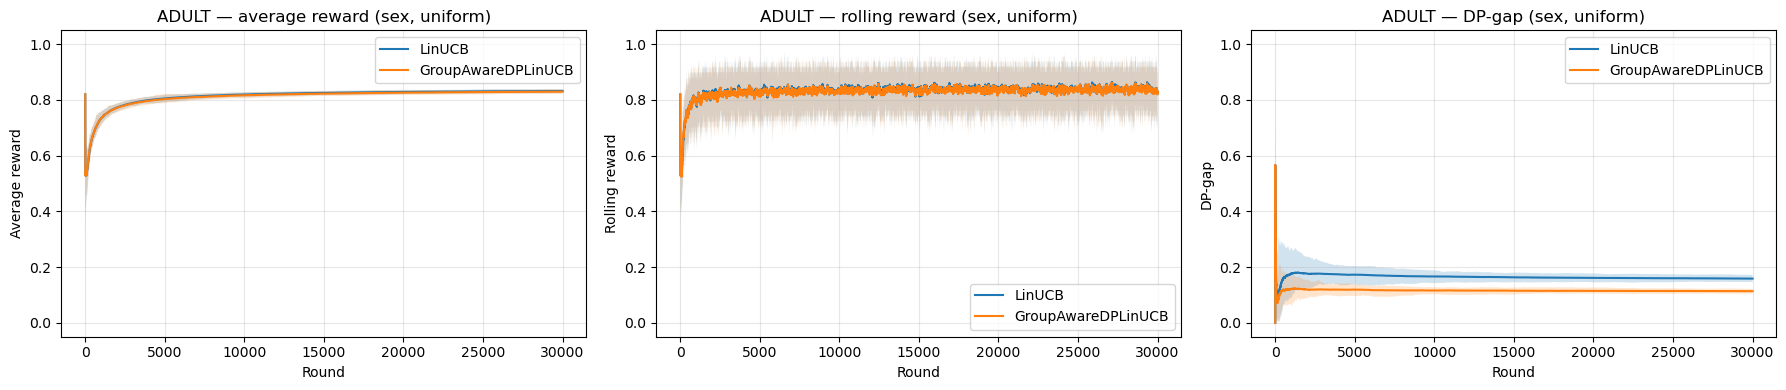

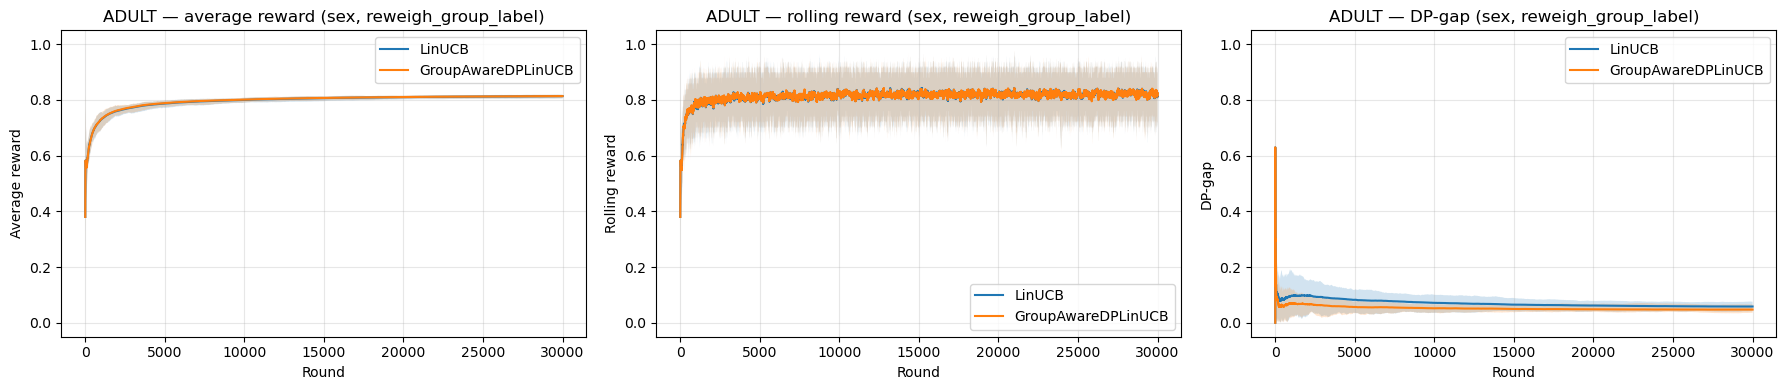

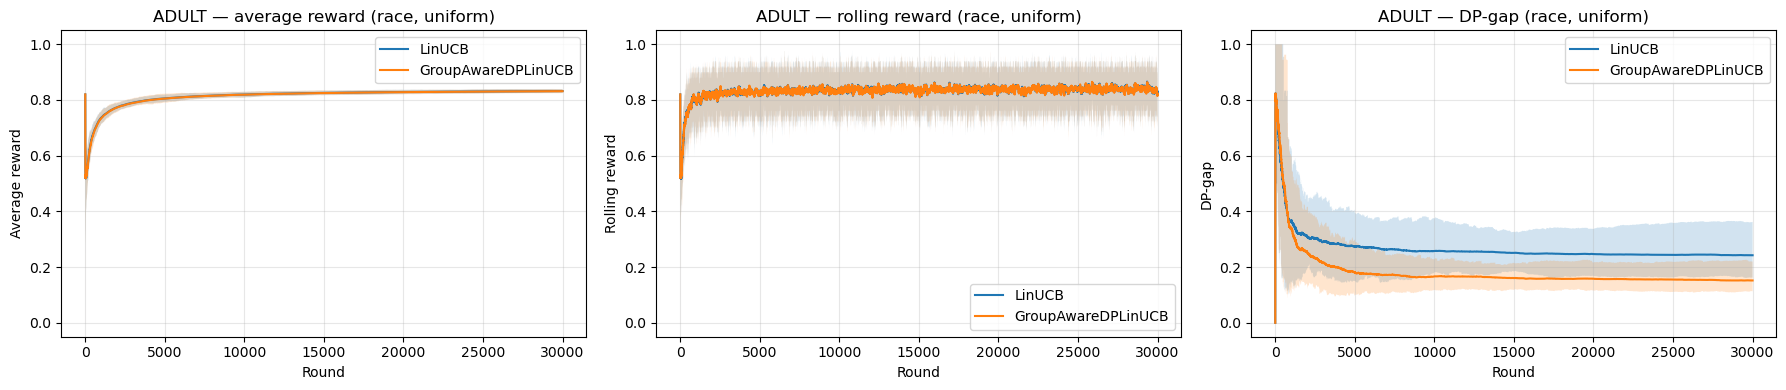

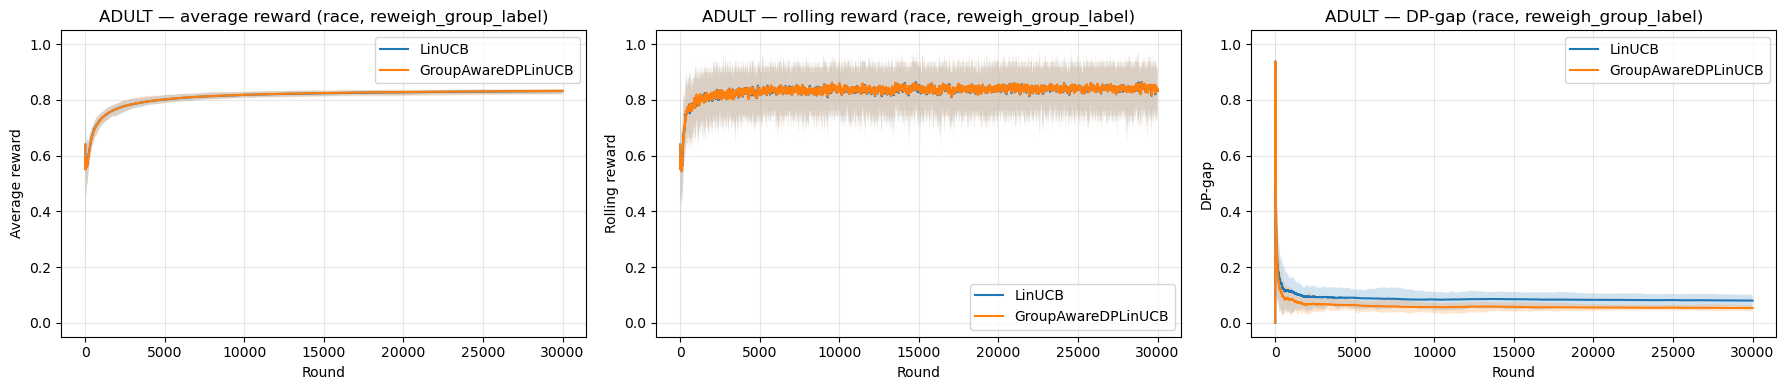

In [9]:
for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSING_OPTIONS:
        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        filters = {
            "dataset": DATASET_NAME,
            "sensitive": sensitive_col,
            "preprocessing": preprocessing,
        }

        plot_average_reward_over_time(
            logs_all,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[0],
            title=f"ADULT — average reward ({sensitive_col}, {preprocessing})",
        )

        plot_rolling_reward(
            logs_all,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[1],
            title=f"ADULT — rolling reward ({sensitive_col}, {preprocessing})",
        )

        plot_dp_gap_over_time(
            logs_all,
            filters=filters,
            policy_order=["LinUCB", "GroupAwareDPLinUCB"],
            ax=axes[2],
            title=f"ADULT — DP-gap ({sensitive_col}, {preprocessing})",
        )

        plt.tight_layout()
        plt.show()


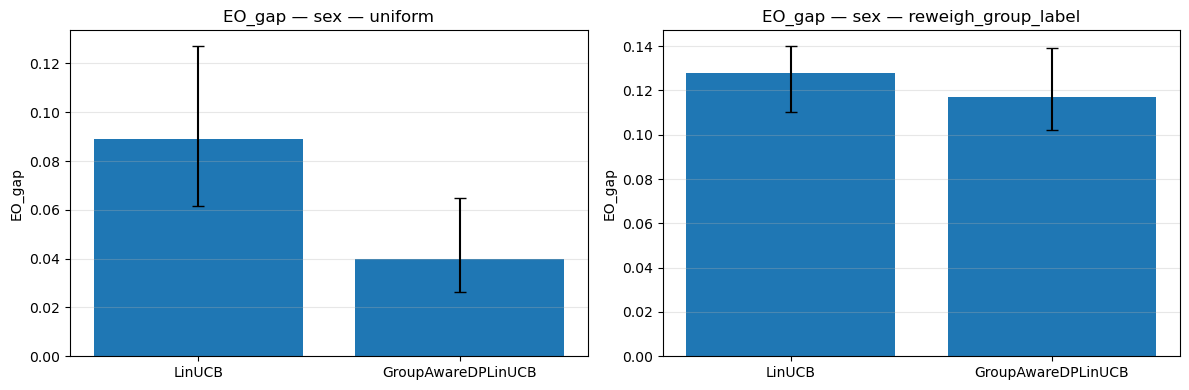

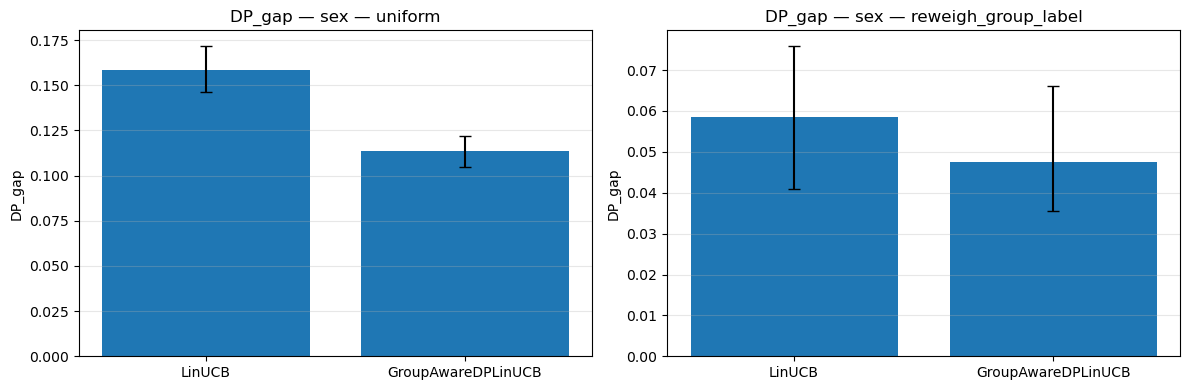

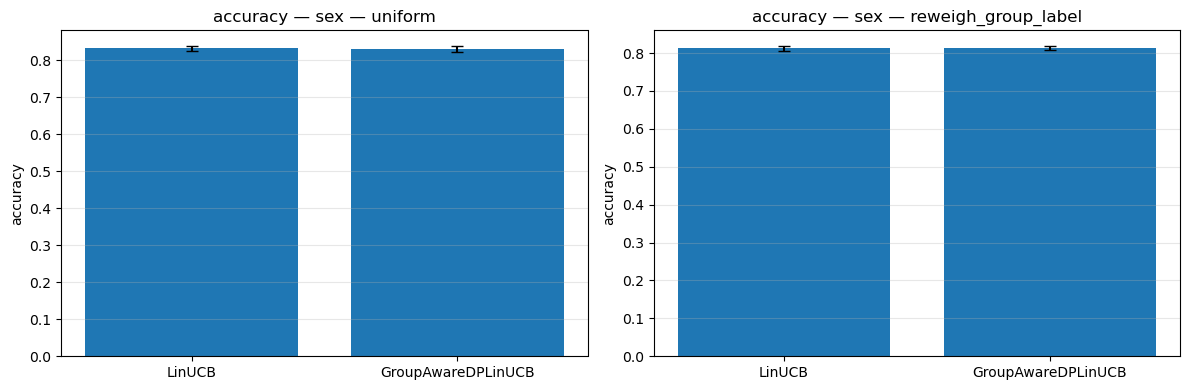

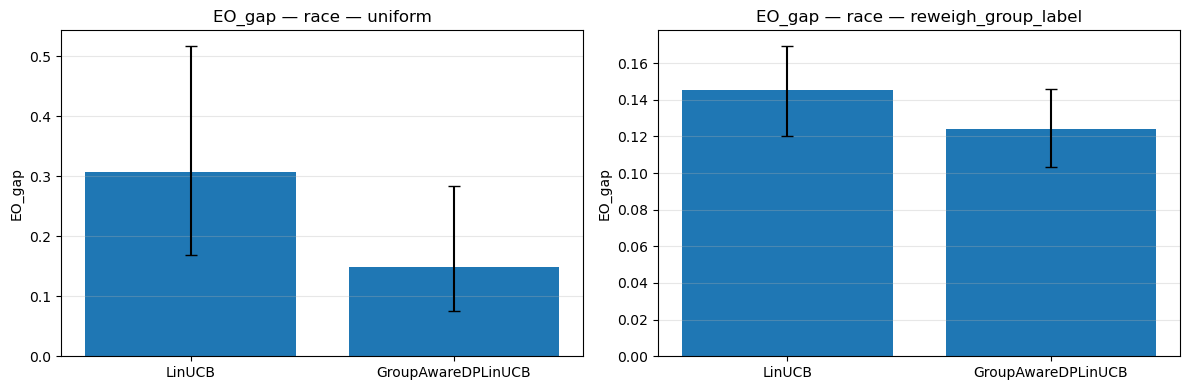

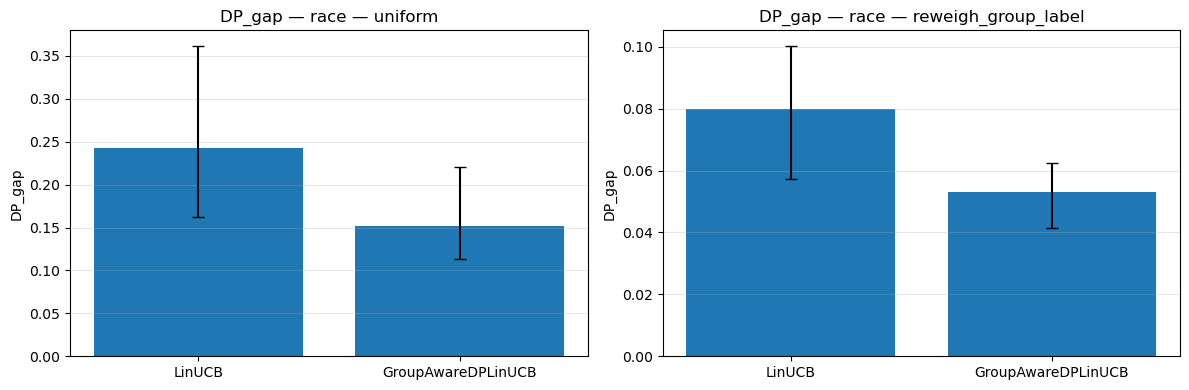

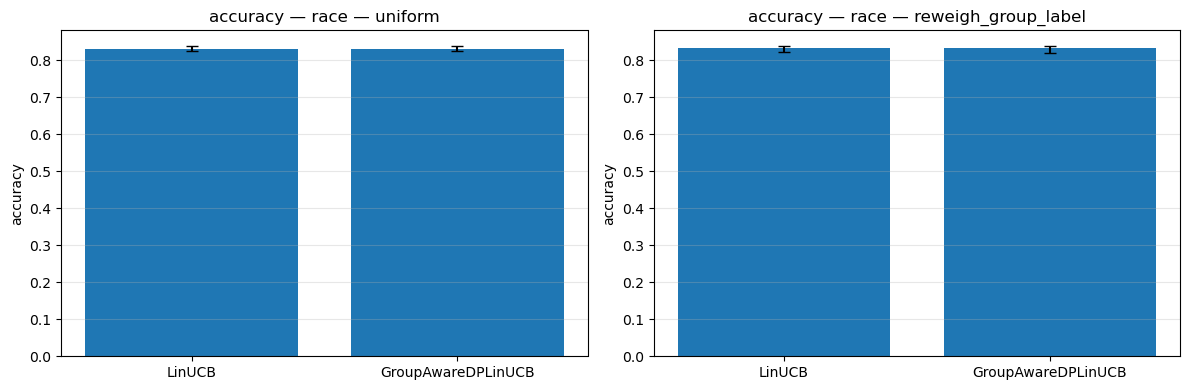

In [10]:
for sensitive_col in SENSITIVE_COLS:
    for metric in ["EO_gap", "DP_gap", "accuracy"]:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, preprocessing in zip(axes, PREPROCESSING_OPTIONS):
            plot_benchmark_bars(
                seed_summary_all,
                metric=metric,
                filters={
                    "dataset": DATASET_NAME,
                    "sensitive": sensitive_col,
                    "preprocessing": preprocessing,
                },
                policy_order=["LinUCB", "GroupAwareDPLinUCB"],
                ax=ax,
                title=f"{metric} — {sensitive_col} — {preprocessing}",
            )
        plt.tight_layout()
        plt.show()


### Export tables

In [11]:
friedman_rows = []
wilcoxon_rows = []

for sensitive_col in SENSITIVE_COLS:
    for preprocessing in PREPROCESSING_OPTIONS:
        subset = seed_summary_all[
            (seed_summary_all["dataset"] == DATASET_NAME)
            & (seed_summary_all["sensitive"] == sensitive_col)
            & (seed_summary_all["preprocessing"] == preprocessing)
        ].copy()

        for metric, lower_is_better in [
            ("EO_gap", True),
            ("DP_gap", True),
            ("CumulativeRegret", True),
            ("accuracy", False),
        ]:
            friedman_df, wilcoxon_df = compare_methods(
                subset,
                value_col=metric,
                method_col="policy",
                seed_col="seed",
                group_cols=["dataset", "sensitive", "preprocessing"],
                lower_is_better=lower_is_better,
            )
            if not friedman_df.empty:
                friedman_rows.append(friedman_df)
            if not wilcoxon_df.empty:
                wilcoxon_rows.append(wilcoxon_df)

friedman_all = pd.concat(friedman_rows, ignore_index=True) if friedman_rows else pd.DataFrame()
wilcoxon_all = pd.concat(wilcoxon_rows, ignore_index=True) if wilcoxon_rows else pd.DataFrame()

display(friedman_all)
display(wilcoxon_all)


""


,dataset,sensitive,preprocessing,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,ADULT,sex,uniform,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.040056,0.088977,-0.048921,1.0,3.552714e-15,GroupAwareDPLinUCB,3.552714e-15
1,ADULT,sex,uniform,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.113569,0.158662,-0.045093,0.0,1.776357e-15,GroupAwareDPLinUCB,1.776357e-15
2,ADULT,sex,uniform,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,5104.220000,5032.040000,72.180000,36.0,6.369656e-09,LinUCB,6.369656e-09
3,ADULT,sex,uniform,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.829859,0.832265,-0.002406,36.0,6.373516e-09,LinUCB,6.373516e-09
4,ADULT,sex,reweigh_group_label,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.117179,0.127979,-0.010800,51.0,6.337864e-11,GroupAwareDPLinUCB,6.337864e-11
5,ADULT,sex,reweigh_group_label,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.047533,0.058467,-0.010934,33.0,5.707435e-12,GroupAwareDPLinUCB,5.707435e-12
6,ADULT,sex,reweigh_group_label,CumulativeRegret,GroupAwareDPLinUCB,LinUCB,50,5582.080000,5588.720000,-6.640000,475.5,1.728963e-01,GroupAwareDPLinUCB,1.728963e-01
7,ADULT,sex,reweigh_group_label,accuracy,GroupAwareDPLinUCB,LinUCB,50,0.813931,0.813709,0.000221,474.5,1.697925e-01,GroupAwareDPLinUCB,1.697925e-01
8,ADULT,race,uniform,EO_gap,GroupAwareDPLinUCB,LinUCB,50,0.148478,0.307558,-0.159080,0.0,1.776357e-15,GroupAwareDPLinUCB,1.776357e-15
9,ADULT,race,uniform,DP_gap,GroupAwareDPLinUCB,LinUCB,50,0.151982,0.242513,-0.090531,0.0,1.776357e-15,GroupAwareDPLinUCB,1.776357e-15


In [12]:
adult_out = CFG.results_dir / DATASET_NAME.lower()
adult_out.mkdir(parents=True, exist_ok=True)

agg_summary.to_csv(adult_out / "adult_aggregated_summary.csv", index=False)
friedman_all.to_csv(adult_out / "adult_friedman_tests.csv", index=False)
wilcoxon_all.to_csv(adult_out / "adult_wilcoxon_tests.csv", index=False)

print("Exported Adult summaries to:", adult_out)


Exported Adult summaries to: results\full\adult


### Interpretation

- compare LinUCB and GroupAwareDPLinUCB on utility  
- compare them on DP-gap and EO-gap  
- discuss whether reweighting improves the fairness–utility trade-off  
- comment separately for `sex` and `race`
